# CLV Validation: Temporal Holdout Backtesting

Validates the two-stage CLV model against the 180-day holdout window (2025-04-04 to 2025-10-01).

1. **Stage 1 validation:** Purchase propensity ranking quality (decile analysis)
2. **Stage 2 validation:** Revenue prediction accuracy for holdout buyers
3. **Combined CLV lift curve:** Does ranking by predicted CLV capture actual holdout revenue?
4. **Revenue calibration:** Total predicted vs actual holdout revenue

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import average_precision_score, roc_auc_score

## 1. Load Scored Data

In [2]:
df = pd.read_csv('../data/processed/clv_scored.csv')
print(f"Loaded {len(df):,} customers")
print(f"Holdout buyers: {(df['actual_holdout_transactions'] > 0).sum():,} ({(df['actual_holdout_transactions'] > 0).mean():.1%})")
print(f"\nKey columns:")
print(f"  p_purchase range:              [{df['p_purchase'].min():.4f}, {df['p_purchase'].max():.4f}]")
print(f"  expected_revenue_if_purchase:   ${df['expected_revenue_if_purchase'].min():.2f} — ${df['expected_revenue_if_purchase'].max():.2f}")
print(f"  clv_180d range:                ${df['clv_180d'].min():.2f} — ${df['clv_180d'].max():.2f}")

Loaded 52,507 customers
Holdout buyers: 6,451 (12.3%)

Key columns:
  p_purchase range:              [0.0000, 0.6987]
  expected_revenue_if_purchase:   $94.08 — $95.88
  clv_180d range:                $0.00 — $66.34


## 2. Stage 1 Validation: Purchase Propensity

How well does `p_purchase` rank customers by likelihood of holdout purchase?

In [3]:
y_true = (df['actual_holdout_transactions'] > 0).astype(int)
y_prob = df['p_purchase']

pr_auc  = average_precision_score(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
baseline = y_true.mean()

print("=== Stage 1: Purchase Propensity (full dataset) ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")

=== Stage 1: Purchase Propensity (full dataset) ===
PR-AUC:   0.3552  (baseline: 0.1229, lift: 2.9x)
ROC-AUC:  0.7731


=== Propensity Decile Analysis ===
                   n_customers  actual_rate  avg_p_purchase  total_holdout_rev
propensity_decile                                                             
1                         5251       0.0101          0.0440          4248.7800
2                         5891       0.0165          0.0734          8547.0500
3                         4610       0.0334          0.0799         13312.5600
4                         5251       0.0554          0.0857         26507.9700
5                         5277       0.0841          0.0950         40102.4000
6                         5225       0.1156          0.1091         54355.3200
7                         5447       0.1452          0.1290         77563.4800
8                         5055       0.1725          0.1536         82383.9801
9                         5252       0.2133          0.1953        103564.4301
10                        5248       0.3859          0.2714        201786.4201


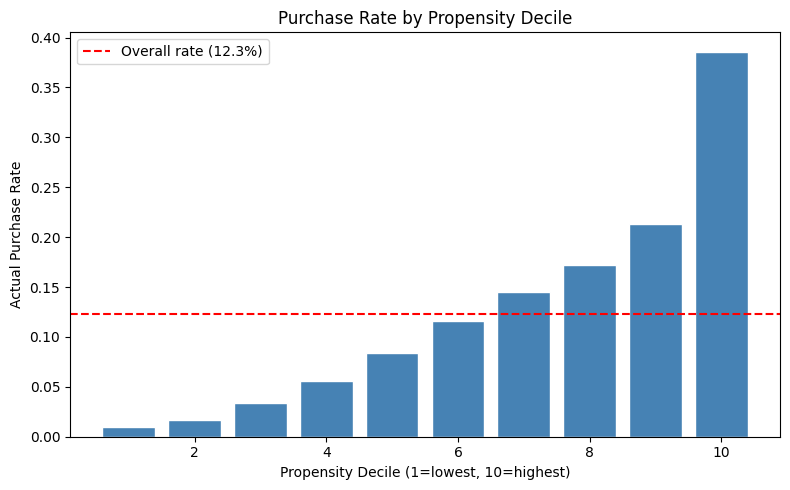

In [4]:
# Decile analysis: bin customers by p_purchase, show actual purchase rate
df['propensity_decile'] = pd.qcut(df['p_purchase'], 10, labels=False, duplicates='drop') + 1

decile_stats = df.groupby('propensity_decile').agg(
    n_customers   = ('user_id', 'count'),
    actual_rate   = ('purchased_in_holdout', 'mean'),
    avg_p_purchase = ('p_purchase', 'mean'),
    total_holdout_rev = ('actual_holdout_revenue', 'sum'),
).round(4)

print("=== Propensity Decile Analysis ===")
print(decile_stats.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'], color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Propensity Decile (1=lowest, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title('Purchase Rate by Propensity Decile')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Stage 2 Validation: Revenue Prediction (Holdout Buyers)

For customers who actually purchased in the holdout, how well does `expected_revenue_if_purchase` match actual revenue?

In [5]:
buyers = df[df['actual_holdout_transactions'] > 0].copy()

# Compare tier-level predictions vs actuals
tier_validation = buyers.groupby('spend_tier').agg(
    n_buyers          = ('user_id', 'count'),
    predicted_avg_rev = ('expected_revenue_if_purchase', 'mean'),
    actual_avg_rev    = ('actual_holdout_revenue', 'mean'),
    actual_median_rev = ('actual_holdout_revenue', 'median'),
).round(2)
tier_validation['error_pct'] = ((tier_validation['predicted_avg_rev'] - tier_validation['actual_avg_rev']) / tier_validation['actual_avg_rev'] * 100).round(1)

print("=== Tier-Level Revenue Validation (holdout buyers) ===")
print(tier_validation.to_string())

# Overall accuracy for buyers
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(buyers['actual_holdout_revenue'], buyers['expected_revenue_if_purchase'])
print(f"\nOverall MAE (buyers only): ${mae:.2f}")
print(f"Mean actual: ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"Mean predicted: ${buyers['expected_revenue_if_purchase'].mean():.2f}")

=== Tier-Level Revenue Validation (holdout buyers) ===
            n_buyers  predicted_avg_rev  actual_avg_rev  actual_median_rev  error_pct
spend_tier                                                                           
High Spend      2111              94.08           94.08              59.99        0.0
Low Spend       2186              95.88           95.88              60.98        0.0
Mid Spend       2154              94.79           94.79              59.99        0.0

Overall MAE (buyers only): $69.13
Mean actual: $94.93
Mean predicted: $94.93


## 4. Combined CLV Lift Curve

The key business metric: if we rank customers by predicted CLV (180d), what % of actual holdout revenue does each top-N% capture?

In [6]:
# Sort by predicted CLV descending
df_ranked = df.sort_values('clv_180d', ascending=False).reset_index(drop=True)
total_actual = df_ranked['actual_holdout_revenue'].sum()

# Cumulative revenue capture
df_ranked['cum_actual_rev'] = df_ranked['actual_holdout_revenue'].cumsum()
df_ranked['cum_actual_pct'] = df_ranked['cum_actual_rev'] / total_actual * 100
df_ranked['customer_pct']   = (df_ranked.index + 1) / len(df_ranked) * 100

# Key checkpoints
for pct in [10, 20, 30, 50]:
    idx = int(len(df_ranked) * pct / 100) - 1
    capture = df_ranked.iloc[idx]['cum_actual_pct']
    print(f"Top {pct}% by CLV captures {capture:.1f}% of actual holdout revenue")

top20_capture = df_ranked.iloc[int(len(df_ranked) * 0.2) - 1]['cum_actual_pct']
print(f"\nTarget: Top 20% >= 50%: {'PASS' if top20_capture >= 50 else 'FAIL'}")

Top 10% by CLV captures 33.0% of actual holdout revenue
Top 20% by CLV captures 49.9% of actual holdout revenue
Top 30% by CLV captures 63.6% of actual holdout revenue
Top 50% by CLV captures 85.0% of actual holdout revenue

Target: Top 20% >= 50%: FAIL


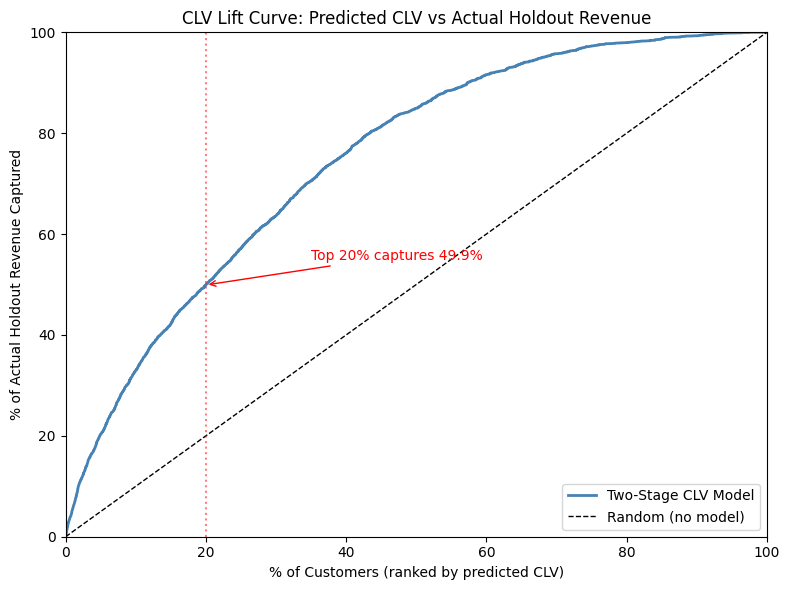

In [7]:
# Lift curve plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df_ranked['customer_pct'], df_ranked['cum_actual_pct'],
        color='steelblue', linewidth=2, label='Two-Stage CLV Model')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random (no model)')

# Annotate key points
ax.axvline(x=20, color='red', linestyle=':', alpha=0.5)
ax.annotate(f'Top 20% captures {top20_capture:.1f}%',
            xy=(20, top20_capture), xytext=(35, top20_capture + 5),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_xlabel('% of Customers (ranked by predicted CLV)')
ax.set_ylabel('% of Actual Holdout Revenue Captured')
ax.set_title('CLV Lift Curve: Predicted CLV vs Actual Holdout Revenue')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Revenue Calibration

In [8]:
total_pred_180d = df['clv_180d'].sum()
total_actual    = df['actual_holdout_revenue'].sum()

print("=== Revenue Calibration ===")
print(f"Total predicted CLV (180d):    ${total_pred_180d:,.0f}")
print(f"Total actual holdout revenue:  ${total_actual:,.0f}")
print(f"Ratio (predicted/actual):      {total_pred_180d / total_actual:.3f}")
print(f"")
print(f"Mean predicted CLV (180d):     ${df['clv_180d'].mean():.2f}")
print(f"Mean actual holdout revenue:   ${df['actual_holdout_revenue'].mean():.2f}")

=== Revenue Calibration ===
Total predicted CLV (180d):    $615,373
Total actual holdout revenue:  $612,372
Ratio (predicted/actual):      1.005

Mean predicted CLV (180d):     $11.72
Mean actual holdout revenue:   $11.66


## 6. Validation Summary

In [9]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"")
print(f"Stage 1 — Purchase Propensity:")
print(f"  PR-AUC:           {pr_auc:.4f} ({pr_auc / baseline:.1f}x over baseline)")
print(f"  ROC-AUC:          {roc_auc:.4f}")
print(f"  Decile lift:      {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x (top vs bottom)")
print(f"")
print(f"Stage 2 — Revenue (tier-based):")
print(f"  MAE (buyers):     ${mae:.2f}")
print(f"")
print(f"Combined CLV:")
print(f"  Top 20% capture:  {top20_capture:.1f}% of holdout revenue")
print(f"  Revenue ratio:    {total_pred_180d / total_actual:.3f}")
print(f"")
print("=" * 60)
print("\nNext: 05_clv_segmentation.ipynb")

VALIDATION SUMMARY

Stage 1 — Purchase Propensity:
  PR-AUC:           0.3552 (2.9x over baseline)
  ROC-AUC:          0.7731
  Decile lift:      38.2x (top vs bottom)

Stage 2 — Revenue (tier-based):
  MAE (buyers):     $69.13

Combined CLV:
  Top 20% capture:  49.9% of holdout revenue
  Revenue ratio:    1.005


Next: 05_clv_segmentation.ipynb
